['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
60000


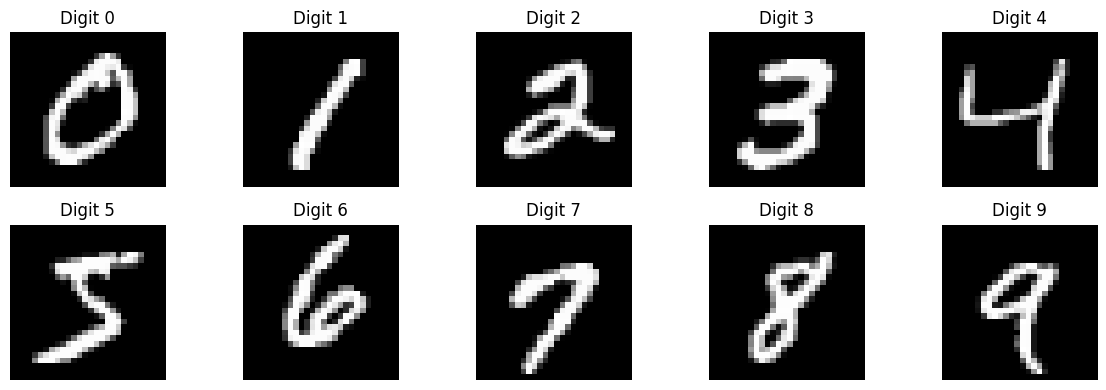

torch.Size([1, 28, 28])

In [2]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import torch.nn as nn

# Load dataset
train_dataset = datasets.MNIST(root='./mnistdata/',train=True,download=True,transform=transforms.ToTensor())

print(train_dataset.classes)
print(len(train_dataset))


# Store one image for each digit
unique_images = [None] * 10
found_labels = [False] * 10

idx = 0

while True:
    image, label = train_dataset[idx]
    if found_labels[label] == False:
        unique_images[label] = image
        found_labels[label] = True
    if all(found_labels):
        break
    idx += 1

# Plot digits
plt.figure(figsize=(12,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(unique_images[i].squeeze(), cmap='gray')
    plt.title(f"Digit {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()
unique_images[0].shape

In [3]:
# Dataset and Dataloader
train_dataset = datasets.MNIST(root='./mnistdata/',train=True,download=True,transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./mnistdata/',train=False,download=True,transform=transforms.ToTensor())

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [4]:
class Net(nn.Module):
    def __init__(self,act_fn, input_size=784, output_size=10, hidden_size=[8,8]):
        
        super().__init__()
        
        layers = []
        layer_sizes = [input_size] + hidden_size

        for il in range(1,len(layer_sizes)):
            layers += [nn.Linear(layer_sizes[il-1], layer_sizes[il]), act_fn]

        layers += [nn.Linear(layer_sizes[-1],output_size)] # Add last layer no activation here
        self.net = nn.ModuleList(layers)
        

    def forward(self, x):
        x = x.view(x.size(0), -1) #MNIST images: [batch, 1, 28, 28], Flatten to [batch, 784]
        
        for fn in self.net:
            x = fn(x)
        return x
        

In [5]:
# Define Net Architecture
model = Net(act_fn=nn.Tanh(), input_size=784, output_size=10, hidden_size=[128,64])
print(model.parameters)

<bound method Module.parameters of Net(
  (net): ModuleList(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)>


In [ ]:

# Define Optimiser
#optimiser = torch.optim.SGD(model.parameters(), lr = 0.1, momentum=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

criterion = torch.nn.CrossEntropyLoss()

from tqdm import tqdm
n_epochs = 10

avg_loss = []
avg_val_loss = []

for epoch in tqdm(range(n_epochs)):
    model.train()
    epoch_loss = 0.0
    for data_input, data_label in train_loader:
        ypred = model(data_input)
        loss = criterion(ypred, data_label)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss.append(epoch_loss / len(train_loader))
    
    # =========================
    # Validation
    # =========================
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for x_val, y_val in val_loader:
            ypred_val = model(x_val)
            valloss = criterion(ypred_val, y_val)
            epoch_val_loss += valloss.item()
    avg_val_loss.append(epoch_val_loss / len(val_loader))

 20%|████████▊                                   | 2/10 [00:58<03:55, 29.44s/it]

In [76]:
# Check training index with max value is the predicted label

x, y = next(iter(train_loader))
output = model(x)
misses = []
print(output.shape, y.shape)
ypred = torch.argmax(output,dim=1)
mask = ypred!=y
misses = torch.where(mask)[0]

for i in range(10): # batch size
    print(f"Pred: {torch.argmax(output[i])}, True: {y[i]}")
print(misses)

torch.Size([64, 10]) torch.Size([64])
Pred: 7, True: 7
Pred: 3, True: 3
Pred: 8, True: 8
Pred: 8, True: 8
Pred: 5, True: 5
Pred: 5, True: 5
Pred: 3, True: 3
Pred: 6, True: 6
Pred: 7, True: 7
Pred: 3, True: 3
tensor([], dtype=torch.int64)


In [81]:
# Measure Accuracy using validation dataset

def evaluate(val_loader):
    model.eval()
    true_preds = 0
    num_preds = 0
    
    missed_images = []
    missed_preds = []
    missed_labels = []
    
    with torch.no_grad():
        for data_input, data_label in val_loader: # entire batch of 64
            output = model(data_input)
            ypred = torch.argmax(output,dim=1)
             # Count correct predictions in batch
            true_preds += (ypred == data_label).sum().item()

            # Store misclassified inputs
            mask = (ypred != data_label)
            missed_images.extend(data_input[mask])
            missed_preds.extend(ypred[mask])
            missed_labels.extend(data_label[mask])
            
            # Total samples in batch
            num_preds += data_label.size(0)
            
            accuracy = true_preds / num_preds

    return accuracy, missed_images, missed_preds, missed_labels

In [82]:
accuracy, missed_images, missed_preds, missed_labels = evaluate(val_loader)
print(f"Accuracy of the model: {100.0*accuracy:4.2f}%")

Accuracy of the model: 97.83%


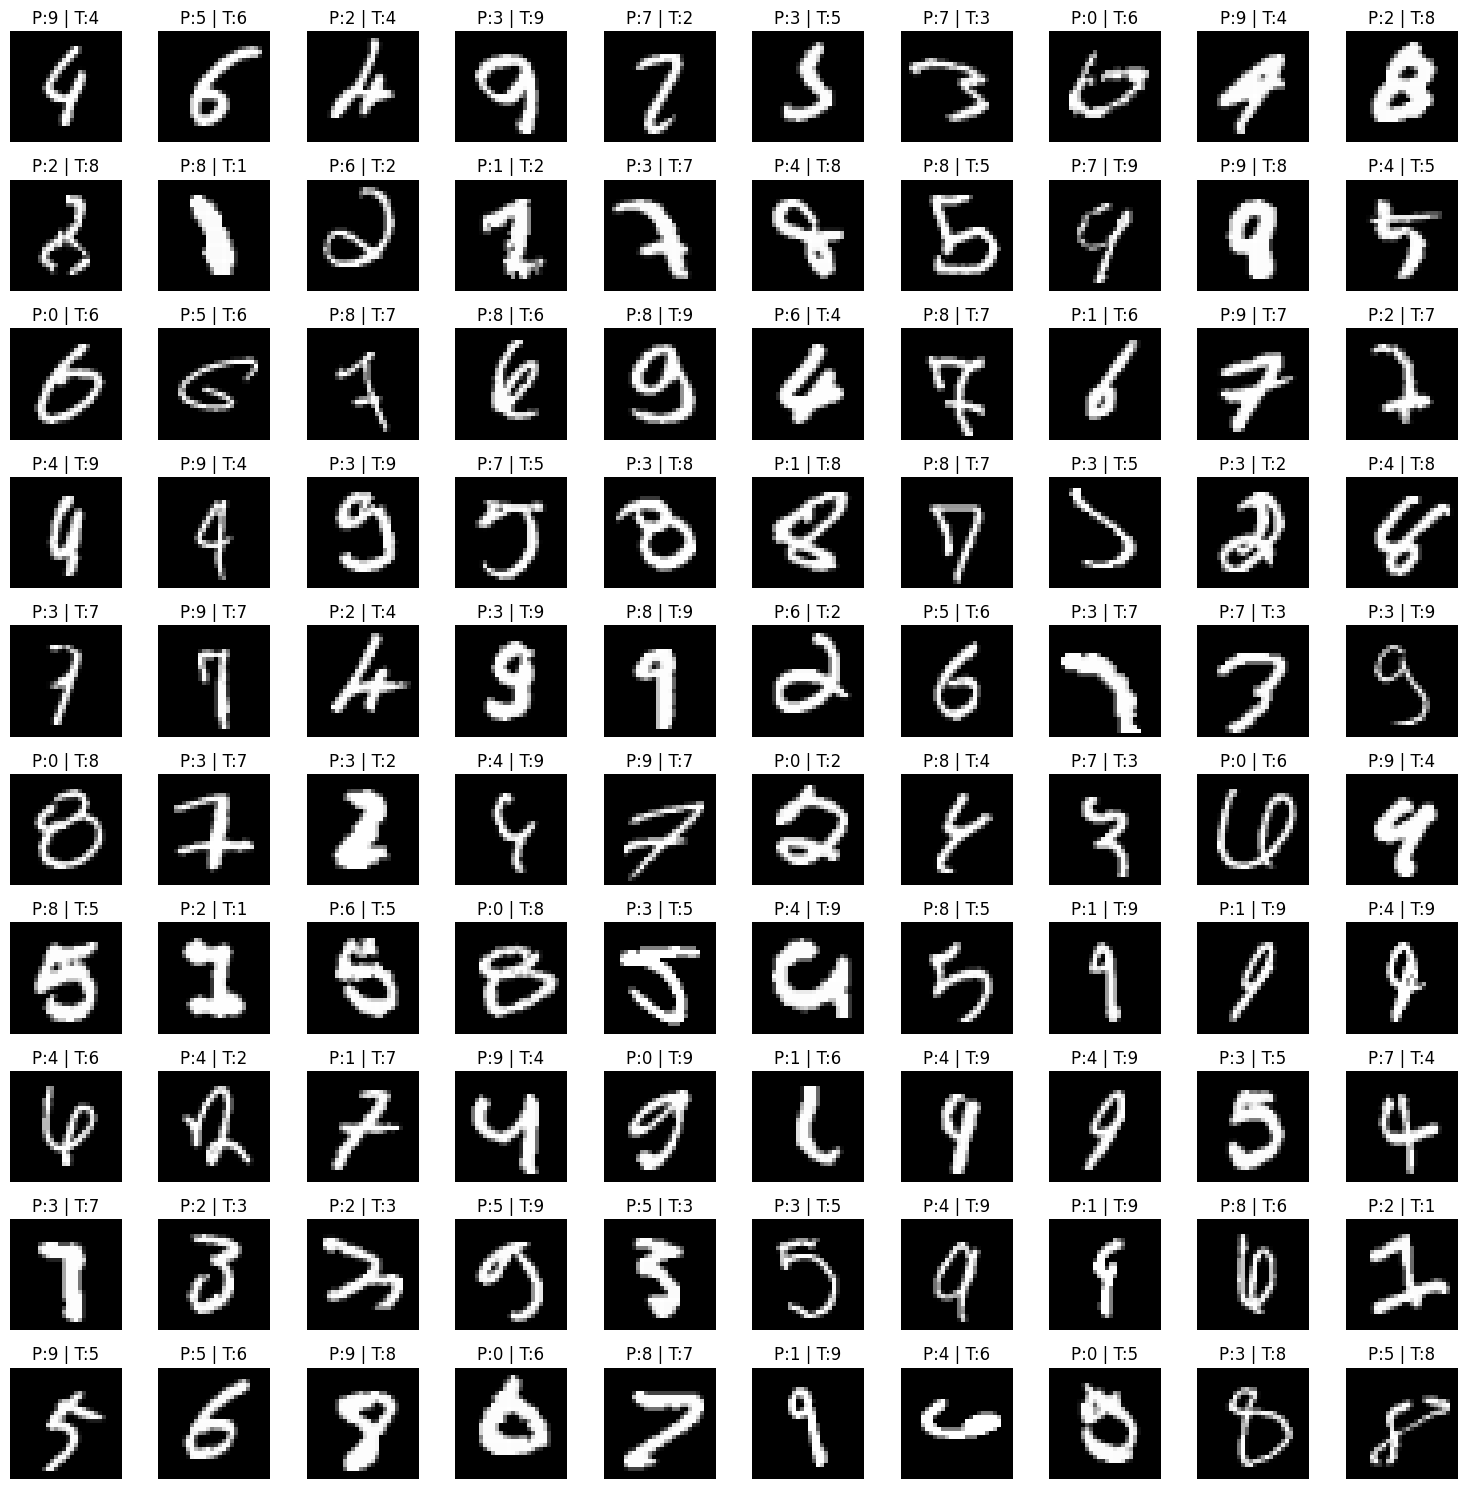

In [88]:
# Plot mis-identified images
n_show = 100
ncols = 10
nrows = n_show // ncols

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15,15)
)

axes = axes.flatten()

for i in range(n_show):

    axes[i].imshow(
        missed_images[i].squeeze(),
        cmap='gray'
    )

    axes[i].set_title(
        f"P:{missed_preds[i].item()} | T:{missed_labels[i].item()}",
        fontsize=12
    )

    axes[i].axis("off")

plt.tight_layout()

plt.show()